In [2]:
# Install necessary libraries: yfinance for stock data, pandas for data manipulation, numpy for numerical operations, and openpyxl for Excel file handling.
!pip install yfinance pandas numpy openpyxl

In [3]:
# Import the pandas library for data manipulation.
import pandas as pd
# Import the requests library to make HTTP requests to the Wikipedia page.
import requests
# Import StringIO from the io module to treat a string as a file.
from io import StringIO
# Import files from google.colab to allow downloading files in Colab.
from google.colab import files

# Define the URL for the Wikipedia page listing S&P 500 companies.
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

# Define a User-Agent header to mimic a web browser, which can be necessary for some websites.
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send an HTTP GET request to the URL with the defined headers.
response = requests.get(url, headers=headers)
# Raise an HTTPError for bad responses (4xx or 5xx).
response.raise_for_status()

# Use pandas to read HTML tables from the response text. StringIO is used to treat the text as a file.
tables = pd.read_html(StringIO(response.text))
# Select the first table, which contains the S&P 500 companies.
sp500 = tables[0]

# Extract the 'Symbol' column, take the first 50 symbols, and convert them to a list.
tickers = sp500["Symbol"].head(50).tolist()

# Create a pandas DataFrame from the list of tickers.
df = pd.DataFrame({"Symbol": tickers})
# Save the DataFrame to a CSV file named "tickers.csv" without the index.
df.to_csv("tickers.csv", index=False)

# Print a confirmation message.
print("Saved tickers.csv")
# Display the first few rows of the DataFrame.
print(df.head())

# Download the generated "tickers.csv" file.
files.download("tickers.csv")

Saved tickers.csv
  Symbol
0    MMM
1    AOS
2    ABT
3   ABBV
4    ACN


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# Install the yfinance library silently.
!pip install yfinance -q

# Import the pandas library for data manipulation.
import pandas as pd
# Import the yfinance library for fetching financial data.
import yfinance as yf

# Read the 'Symbol' column from the "tickers.csv" file and convert it to a list.
tickers = pd.read_csv("tickers.csv")["Symbol"].tolist()

# Initialize an empty list to store all fetched earnings data.
all_data = []

# Loop through each ticker symbol.
for t in tickers:
    try:
        # Create a Ticker object for the current symbol.
        stock = yf.Ticker(t)
        # Get the earnings dates for the stock, limiting to the past 8 entries.
        ed = stock.get_earnings_dates(limit=8)
        # Check if earnings data is not empty or None.
        if ed is not None and len(ed) > 0:
            # Reset the index of the earnings data DataFrame.
            ed = ed.reset_index()
            # Add a 'Symbol' column to the earnings data.
            ed["Symbol"] = t
            # Append the earnings data to the all_data list.
            all_data.append(ed)
    except Exception as e:
        # Print an error message if fetching data for a ticker fails.
        print("Error with", t, e)

# Concatenate all individual earnings DataFrames into a single DataFrame.
earnings = pd.concat(all_data, ignore_index=True)
# Save the combined earnings DataFrame to a CSV file named "earnings.csv" without the index.
earnings.to_csv("earnings.csv", index=False)

# Print a confirmation message.
print("Saved earnings.csv")
# Display the first few rows of the consolidated earnings DataFrame.
print(earnings.head())

Saved earnings.csv
              Earnings Date  EPS Estimate  Reported EPS  Surprise(%) Symbol
0 2026-07-21 08:00:00-04:00          2.22           NaN          NaN    MMM
1 2026-04-21 06:00:00-04:00          1.98          2.14         7.88    MMM
2 2026-01-20 06:00:00-05:00          1.79          1.07       -40.38    MMM
3 2025-10-21 06:00:00-04:00          2.07          2.19         5.60    MMM
4 2025-07-18 06:00:00-04:00          2.01          2.16         7.37    MMM


In [5]:
tickers = pd.read_csv("tickers.csv")["Symbol"].tolist()

prices = yf.download(tickers, start="2020-01-01", auto_adjust=False)

adj_close = prices["Adj Close"]
adj_close.to_csv("prices.csv")

print("Saved prices.csv")
print(adj_close.head())

[*********************100%***********************]  50 of 50 completed


Saved prices.csv
Ticker              A       AAPL       ABBV  ABNB        ABT       ACGL  \
Date                                                                      
2020-01-02  82.210449  72.333870  68.696251   NaN  77.328743  41.268997   
2020-01-03  80.890480  71.630653  68.044189   NaN  76.386024  41.221451   
2020-01-06  81.129631  72.201416  68.581169   NaN  76.786217  41.383106   
2020-01-07  81.378304  71.861855  68.189957   NaN  76.359329  41.040779   
2020-01-08  82.181755  73.017838  68.673256   NaN  76.670631  40.631893   

Ticker             ACN        ADBE         ADI        ADM  ...       ARES  \
Date                                                       ...              
2020-01-02  190.896164  334.429993  107.497208  38.257217  ...  28.984444   
2020-01-03  190.578232  331.809998  105.604881  38.182556  ...  28.739784   
2020-01-06  189.333725  333.709991  104.364136  37.883858  ...  29.025221   
2020-01-07  185.246033  333.390015  106.738503  37.427540  ...  28.90288

In [6]:
# Import the pandas library for data manipulation.
import pandas as pd
# Import the yfinance library for fetching financial data.
import yfinance as yf

# Load the ticker symbols from 'tickers.csv' into a DataFrame.
tickers = pd.read_csv("tickers.csv")
# Load the earnings data from 'earnings.csv' into a DataFrame.
earnings = pd.read_csv("earnings.csv")

# Convert the 'Earnings Date' column in the earnings DataFrame to datetime objects.
earnings["Earnings Date"] = pd.to_datetime(earnings["Earnings Date"])

# Initialize an empty list to store all the processed rows of data.
all_rows = []

# Iterate through each ticker symbol in the 'tickers' DataFrame.
for symbol in tickers["Symbol"]:
    try:
        # Create a yfinance Ticker object for the current symbol.
        stock = yf.Ticker(symbol)
        # Fetch historical price data for the stock, starting from 2020-01-01.
        # 'auto_adjust=True' automatically adjusts prices for splits and dividends.
        price_data = stock.history(start="2020-01-01", auto_adjust=True)

        # Filter the earnings DataFrame to get only the earnings data for the current symbol.
        stock_earnings = earnings[earnings["Symbol"] == symbol]

        # Iterate through each earnings report for the current stock.
        for _, row in stock_earnings.iterrows():
            # Get the earnings date for the current report.
            earn_date = row["Earnings Date"]

            # Reset the index of price_data to make 'Date' a regular column.
            price_data_reset = price_data.reset_index()
            # Ensure the 'Date' column is in datetime format.
            price_data_reset["Date"] = pd.to_datetime(price_data_reset["Date"])
            # Filter for prices on or after the earnings date.
            future_prices = price_data_reset[price_data_reset["Date"] >= earn_date]

            # If no price data is found on or after the earnings date, skip this earnings report.
            if len(future_prices) == 0:
                continue

            # Get the closing price on the first trading day on or after the earnings date (base price).
            base_price = future_prices.iloc[0]["Close"]

            # Get the closing price one day after the earnings date, if available.
            if len(future_prices) > 1:
                price_1d = future_prices.iloc[1]["Close"]
            else:
                # If not enough data, skip this report.
                continue

            # Get the closing price five days after the earnings date, if available.
            if len(future_prices) > 5:
                price_5d = future_prices.iloc[5]["Close"]
            else:
                # If not enough data, set to None.
                price_5d = None

            # Get the closing price thirty days after the earnings date, if available.
            if len(future_prices) > 30:
                price_30d = future_prices.iloc[30]["Close"]
            else:
                # If not enough data, set to None.
                price_30d = None

            # Convert the current earnings report row to a dictionary.
            row_data = row.to_dict()
            # Add the calculated base price to the dictionary.
            row_data["Base Price"] = base_price
            # Add the 1-day post-earnings price.
            row_data["Price_1D"] = price_1d
            # Add the 5-day post-earnings price.
            row_data["Price_5D"] = price_5d
            # Add the 30-day post-earnings price.
            row_data["Price_30D"] = price_30d

            # Calculate the 1-day return percentage.
            row_data["Return_1D_%"] = ((price_1d - base_price) / base_price) * 100
            # Calculate the 5-day return percentage, if price_5d is available.
            row_data["Return_5D_%"] = ((price_5d - base_price) / base_price) * 100 if price_5d else None
            # Calculate the 30-day return percentage, if price_30d is available.
            row_data["Return_30D_%"] = ((price_30d - base_price) / base_price) * 100 if price_30d else None

            # Append the processed row data to the list.
            all_rows.append(row_data)

    except Exception as e:
        # Print any errors that occur during data fetching or processing for a symbol.
        print("Error:", symbol, e)

# Concatenate all processed rows into a single DataFrame.
final_df = pd.DataFrame(all_rows)
# Save the final DataFrame to a CSV file named "final_earnings_data.csv" without the index.
final_df.to_csv("final_earnings_data.csv", index=False)

# Print a confirmation message.
print("Saved final_earnings_data.csv")
# Display the first few rows of the final DataFrame.
print(final_df.head())

/tmp/ipykernel_21649/1195806645.py:12: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  earnings["Earnings Date"] = pd.to_datetime(earnings["Earnings Date"])


Saved final_earnings_data.csv
               Earnings Date  EPS Estimate  Reported EPS  Surprise(%) Symbol  \
0  2026-04-21 06:00:00-04:00          1.98          2.14         7.88    MMM   
1  2026-01-20 06:00:00-05:00          1.79          1.07       -40.38    MMM   
2  2025-10-21 06:00:00-04:00          2.07          2.19         5.60    MMM   
3  2025-07-18 06:00:00-04:00          2.01          2.16         7.37    MMM   
4  2025-04-22 06:00:00-04:00          1.77          1.88         6.42    MMM   

   Base Price    Price_1D    Price_5D   Price_30D  Return_1D_%  Return_5D_%  \
0  145.029938  144.094772  143.129761  152.770004    -0.644809    -1.310196   
1  154.385239  159.089691  154.444656  155.406281     3.047217     0.038487   
2  164.917755  169.227325  162.353714  167.646851     2.613163    -1.554739   
3  150.013855  148.423599  149.257996  152.136963    -1.060073    -0.503860   
4  132.910660  135.665390  135.694687  143.574310     2.072618     2.094661   

   Return_30D_

In [7]:

df = pd.read_csv("final_earnings_data.csv")

# Keep only useful columns
keep_cols = [
    "Symbol",
    "Earnings Date",
    "Reported EPS",
    "Estimated EPS",
    "Surprise(%)",
    "Return_1D_%",
    "Return_5D_%",
    "Return_30D_%"
]

# Keep only columns that exist
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols]

# Remove empty rows
df = df.dropna()

# Save cleaned file
df.to_csv("clean_earnings_data.csv", index=False)

print("Saved clean_earnings_data.csv")
print(df.head())

Saved clean_earnings_data.csv
  Symbol              Earnings Date  Reported EPS  Surprise(%)  Return_1D_%  \
0    MMM  2026-04-21 06:00:00-04:00          2.14         7.88    -0.644809   
1    MMM  2026-01-20 06:00:00-05:00          1.07       -40.38     3.047217   
2    MMM  2025-10-21 06:00:00-04:00          2.19         5.60     2.613163   
3    MMM  2025-07-18 06:00:00-04:00          2.16         7.37    -1.060073   
4    MMM  2025-04-22 06:00:00-04:00          1.88         6.42     2.072618   

   Return_5D_%  Return_30D_%  
0    -1.310196      5.336875  
1     0.038487      0.661360  
2    -1.554739      1.654822  
3    -0.503860      1.415275  
4     2.094661      8.023172  


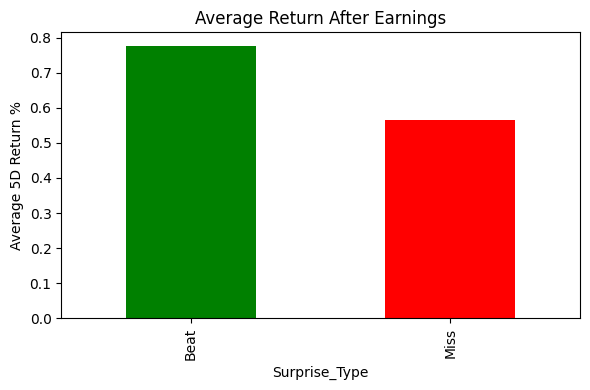

In [8]:
# Import the pandas library for data manipulation.
import pandas as pd
# Import the matplotlib.pyplot library for creating visualizations.
import matplotlib.pyplot as plt

# Load the cleaned earnings data from 'clean_earnings_data.csv' into a DataFrame.
df = pd.read_csv("clean_earnings_data.csv")

# Convert the 'Return_5D_%' column to numeric, coercing errors to NaN.
df["Return_5D_%"] = pd.to_numeric(df["Return_5D_%"] , errors="coerce")

# Drop rows where 'Return_5D_%' is NaN (empty).
df = df.dropna(subset=["Return_5D_%"])

# Check if the 'Surprise(%)' column exists in the DataFrame.
if "Surprise(%)" in df.columns:
    # Convert 'Surprise(%)' to numeric, coercing errors to NaN.
    df["Surprise(%)"] = pd.to_numeric(df["Surprise(%)"] , errors="coerce")
    # Create a 'Surprise_Type' column: 'Beat' if Surprise(%) > 0, else 'Miss'.
    df["Surprise_Type"] = df["Surprise(%)"].apply(lambda x: "Beat" if x > 0 else "Miss")
    # Group by 'Surprise_Type' and calculate the mean of 'Return_5D_%'.
    chart_data = df.groupby("Surprise_Type")["Return_5D_%"] .mean()
else:
    # If 'Surprise(%)' column does not exist, calculate the overall mean of 'Return_5D_%'.
    chart_data = df["Return_5D_%"] .mean()

# Create a new figure for the plot with a specified size.
plt.figure(figsize=(6,4))
# Check if chart_data is a pandas Series (meaning it was grouped by 'Surprise_Type').
if isinstance(chart_data, pd.Series):
    # If it's a Series, create a bar plot with different colors for 'Beat' and 'Miss'.
    chart_data.plot(kind="bar", color=["green", "red"])
    # Set the y-axis label.
    plt.ylabel("Average 5D Return %")
    # Set the title of the plot.
    plt.title("Average Return After Earnings")
else:
    # If it's not a Series (meaning only overall average), create a single bar plot.
    plt.bar(["Average 5D Return"], [chart_data], color="blue")
    # Set the y-axis label.
    plt.ylabel("Return %")
    # Set the title of the plot.
    plt.title("Average 5D Return")

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Display the plot.
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv("clean_earnings_data.csv")

df["Surprise(%)"] = pd.to_numeric(df["Surprise(%)"], errors="coerce")

def classify_surprise(x):
    if x >= 10:
        return "Strong Beat"
    elif x > 0:
        return "Beat"
    elif x > -10:
        return "Miss"
    else:
        return "Strong Miss"

df["Surprise_Category"] = df["Surprise(%)"].apply(classify_surprise)

summary = df.groupby("Surprise_Category")[[
    "Return_1D_%",
    "Return_5D_%",
    "Return_30D_%"
]].mean()

print(summary)

summary.to_csv("surprise_category_analysis.csv")

print("\nSaved surprise_category_analysis.csv")

                   Return_1D_%  Return_5D_%  Return_30D_%
Surprise_Category                                        
Beat                  0.222132     0.631394      1.461288
Miss                  0.203560     1.077124      2.102224
Strong Beat           0.319225     0.983797      2.698674
Strong Miss          -0.098499    -0.420674      0.212148

Saved surprise_category_analysis.csv


In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("clean_earnings_data.csv")

df["Surprise(%)"] = pd.to_numeric(df["Surprise(%)"], errors="coerce")
df["Return_5D_%"] = pd.to_numeric(df["Return_5D_%"], errors="coerce")

strategy = df[df["Surprise(%)"] > 10].copy()

total_trades = len(strategy)

winning_trades = len(
    strategy[strategy["Return_5D_%"] > 0]
)

win_rate = (winning_trades / total_trades) * 100

avg_return = strategy["Return_5D_%"].mean()

best_trade = strategy["Return_5D_%"].max()

worst_trade = strategy["Return_5D_%"].min()

print("===== STRATEGY RESULTS =====")
print(f"Total Trades: {total_trades}")
print(f"Winning Trades: {winning_trades}")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Average Return: {avg_return:.2f}%")
print(f"Best Trade: {best_trade:.2f}%")
print(f"Worst Trade: {worst_trade:.2f}%")

===== STRATEGY RESULTS =====
Total Trades: 377
Winning Trades: 216
Win Rate: 57.29%
Average Return: 0.98%
Best Trade: 36.15%
Worst Trade: -25.63%


In [11]:
# Import libraries
import pandas as pd
import numpy as np

# Load earnings dataset
df = pd.read_csv("clean_earnings_data.csv")

# Convert relevant columns to numeric
df["Surprise(%)"] = pd.to_numeric(df["Surprise(%)"], errors="coerce")
df["Return_5D_%"] = pd.to_numeric(df["Return_5D_%"], errors="coerce")

# Use same strategy:
# Buy stocks with earnings surprise > 10%
strategy = df[df["Surprise(%)"] > 10].copy()

# Convert percentage returns to decimal format
# Example:
# 5% becomes 0.05
returns = strategy["Return_5D_%"] / 100

# Volatility measures risk
# Higher volatility means returns fluctuate more
volatility = returns.std()

# Sharpe Ratio measures return generated per unit risk
sharpe_ratio = returns.mean() / returns.std()

# Create cumulative return curve
# Simulates portfolio growth over time
cumulative = (1 + returns).cumprod()

# Highest portfolio value achieved so far
rolling_max = cumulative.cummax()

# Drawdown measures fall from previous peak
drawdown = (cumulative - rolling_max) / rolling_max

# Maximum drawdown represents largest decline
max_drawdown = drawdown.min()

# Print risk metrics
print("===== RISK METRICS =====")
print(f"Volatility: {volatility:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"Maximum Drawdown: {max_drawdown:.4f}")

===== RISK METRICS =====
Volatility: 0.0550
Sharpe Ratio: 0.1788
Maximum Drawdown: -0.5421


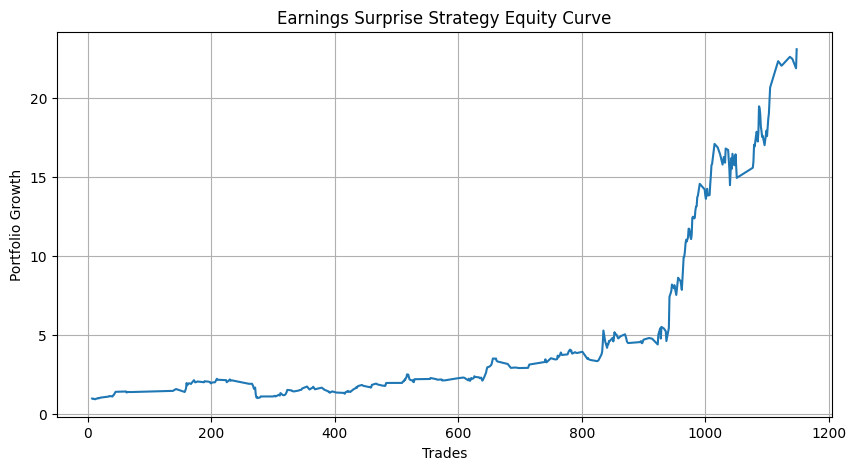

In [12]:
df["Surprise(%)"]=pd.to_numeric(df["Surprise(%)"],errors="coerce")
df["Return_5D_%"]=pd.to_numeric(df["Return_5D_%"],errors="coerce")

strategy=df[df["Surprise(%)"]>10].copy()

returns=strategy["Return_5D_%"]/100

equity_curve=(1+returns).cumprod()
plt.figure(figsize=(10,5))
plt.plot(equity_curve)
plt.title("Earnings Surprise Strategy Equity Curve")
plt.xlabel("Trades")
plt.ylabel("Portfolio Growth")
plt.grid(True)
plt.show()

In [14]:
# Import pandas
import pandas as pd

# Load dataset
df = pd.read_csv("clean_earnings_data.csv")

# Convert surprise column to numeric
df["Surprise(%)"] = pd.to_numeric(df["Surprise(%)"], errors="coerce")

# Recreate surprise classification categories
def classify_surprise(x):

    if x >= 10:
        return "Strong Beat"

    elif x > 0:
        return "Beat"

    elif x > -10:
        return "Miss"

    else:
        return "Strong Miss"

# Create category column
df["Surprise_Category"] = df["Surprise(%)"].apply(classify_surprise)

# Export final dashboard-ready dataset
df.to_csv(
    "powerbi_earnings_dashboard.csv",
    index=False
)

print("Power BI file exported successfully.")

Power BI file exported successfully.


In [15]:
from google.colab import files

files.download("powerbi_earnings_dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

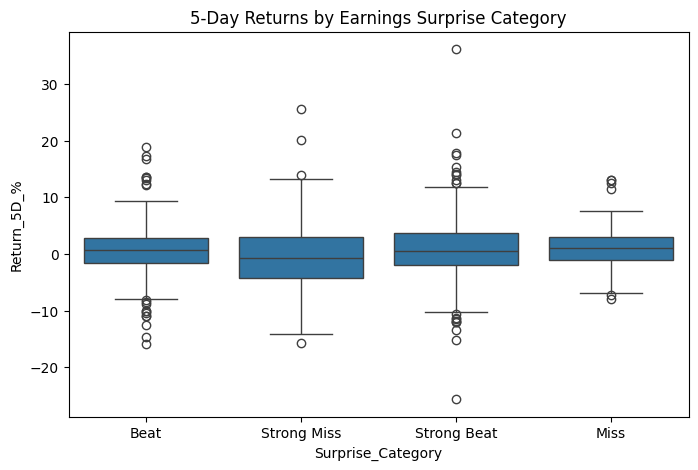

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Surprise_Category",
    y="Return_5D_%",
    data=df
)

plt.title("5-Day Returns by Earnings Surprise Category")
plt.show()